# Dataset Description
## Traffic Fatalities in 2026, up to Aptil

**Source**: Agencia Nacional de Seguridad Vial.

**Download**: [download](https://ansv.gov.co/es/observatorio/estadisticas/personas-fallecidas-en-siniestros-viales)

# Code
## Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json
import unicodedata
import matplotlib.cm as cm
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize

## Load data

In [21]:
path = "./data/accidentes.csv"
geo_path = "./data/colombia_departments.geojson"

df = pd.read_csv(path, encoding="utf-8", sep=";")

with open(geo_path, encoding="utf-8") as f:
    geo = json.load(f)

## Clean data Map

In [22]:
df = df[df["AnoHecho"] == 2026]

def normalize_name(name: str) -> str:
    ascii_name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    ascii_name = ascii_name.upper().replace(".", "").replace(",", "")
    return " ".join(ascii_name.split())


geo_name_to_dpto = {
    normalize_name(feat["properties"]["NOMBRE_DPT"]): feat["properties"]["DPTO"]
    for feat in geo["features"]
}
geo_name_to_dpto.update({
    "BOGOTA DC": "11",
    "NORTE SANTANDER": "54",
    "ARCHIPIELAGO SAN ANDRES PROVIDENCIA Y SANTA CATALINA": "88",
})

df["DPTO"] = df["Departamento"].map(lambda s: geo_name_to_dpto.get(normalize_name(s)))
deaths_by_dept = df.dropna(subset=["DPTO"]).groupby("DPTO").size()

sanandres_box = {"lon": (-79.0, -75.9), "lat": (10.9, 13.3)}

## Plot Department map

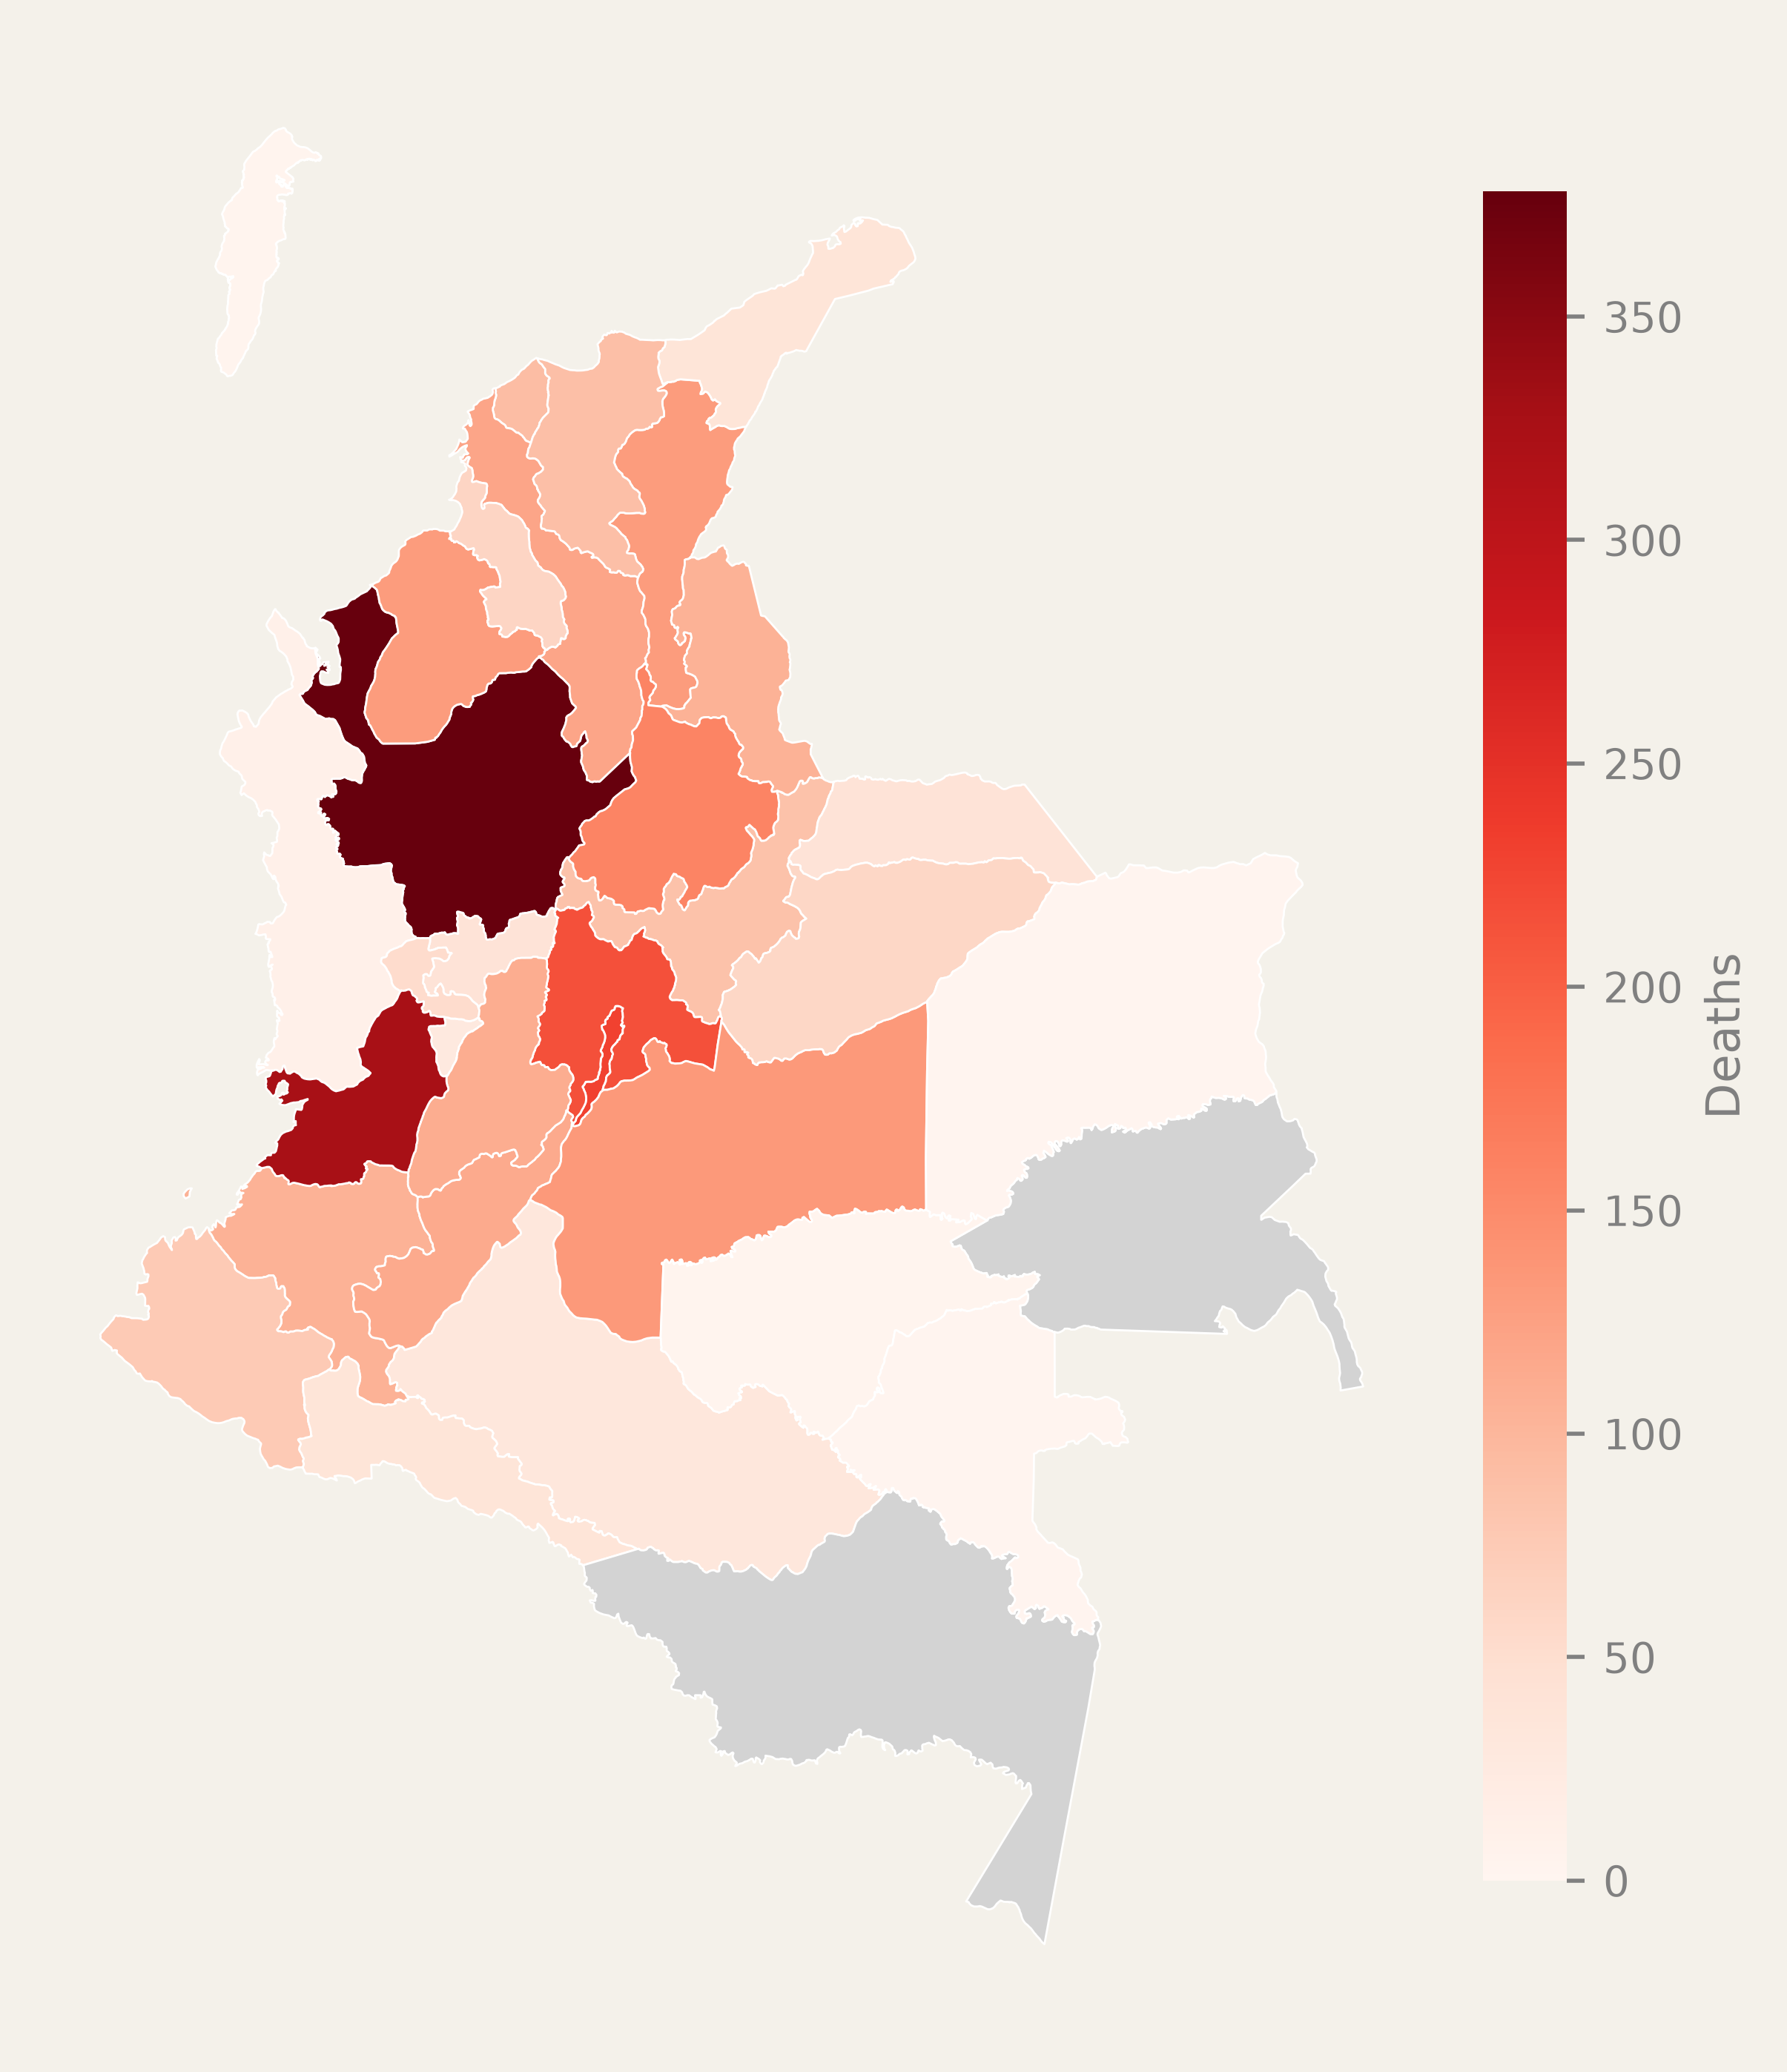

In [23]:
background = "#F4F1EA"
men_color = "#4a90e2"
women_color = "#FF6B9D"
missing_color = "#D3D3D3"

def exterior_rings(geometry: dict) -> list:
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"][0]]
    return [poly[0] for poly in geometry["coordinates"]]


def fit_box(rings: list, box: dict) -> list:
    xs = [x for r in rings for x, _ in r]
    ys = [y for r in rings for _, y in r]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bx0, bx1 = box["lon"]
    by0, by1 = box["lat"]
    scale = min((bx1 - bx0) / (x1 - x0), (by1 - by0) / (y1 - y0))
    ox = bx0 + ((bx1 - bx0) - (x1 - x0) * scale) / 2
    oy = by0 + ((by1 - by0) - (y1 - y0) * scale) / 2
    return [[(ox + (x - x0) * scale, oy + (y - y0) * scale) for x, y in r]
            for r in rings]

cmap = cm.Reds
norm = Normalize(vmin=0, vmax=deaths_by_dept.max())

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

patches, colors = [], []
for feat in geo["features"]:
    code = feat["properties"]["DPTO"]
    val = deaths_by_dept.get(code)
    color = missing_color if val is None else cmap(norm(val))
    rings = exterior_rings(feat["geometry"])
    if code == "88":
        def bbox_area(r):
            xs = [x for x, _ in r]
            ys = [y for _, y in r]
            return (max(xs) - min(xs)) * (max(ys) - min(ys))
        rings = fit_box([max(rings, key=bbox_area)], sanandres_box)
    for ring in rings:
        patches.append(Polygon(ring, closed=True))
        colors.append(color)

ax.add_collection(PatchCollection(patches, facecolor=colors, edgecolor="white", linewidth=0.4))
ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Deaths", fontsize=9, color="gray")
cbar.ax.tick_params(labelsize=8, colors="gray")
cbar.outline.set_visible(False)

plt.show()

## Clear data Gender by role in traffic

In [24]:
actor_en = {
    "USUARIO DE MOTO": "Motorcycle",
    "PEATÓN": "Pedestrian",
    "USUARIO DE VEHÍCULO": "Car",
    "USUARIO DE BICICLETA": "Bicycle",
    "USUARIO OTROS": "Other",
}

role_gender = (
    df[df["ActorVial"] != "SIN INFORMACIÓN"]
    .groupby(["ActorVial", "Sexo"])
    .size()
    .unstack(fill_value=0)
    .sort_values("HOMBRE", ascending=False)
    .rename(index=actor_en)
)

## Plot Gender By role

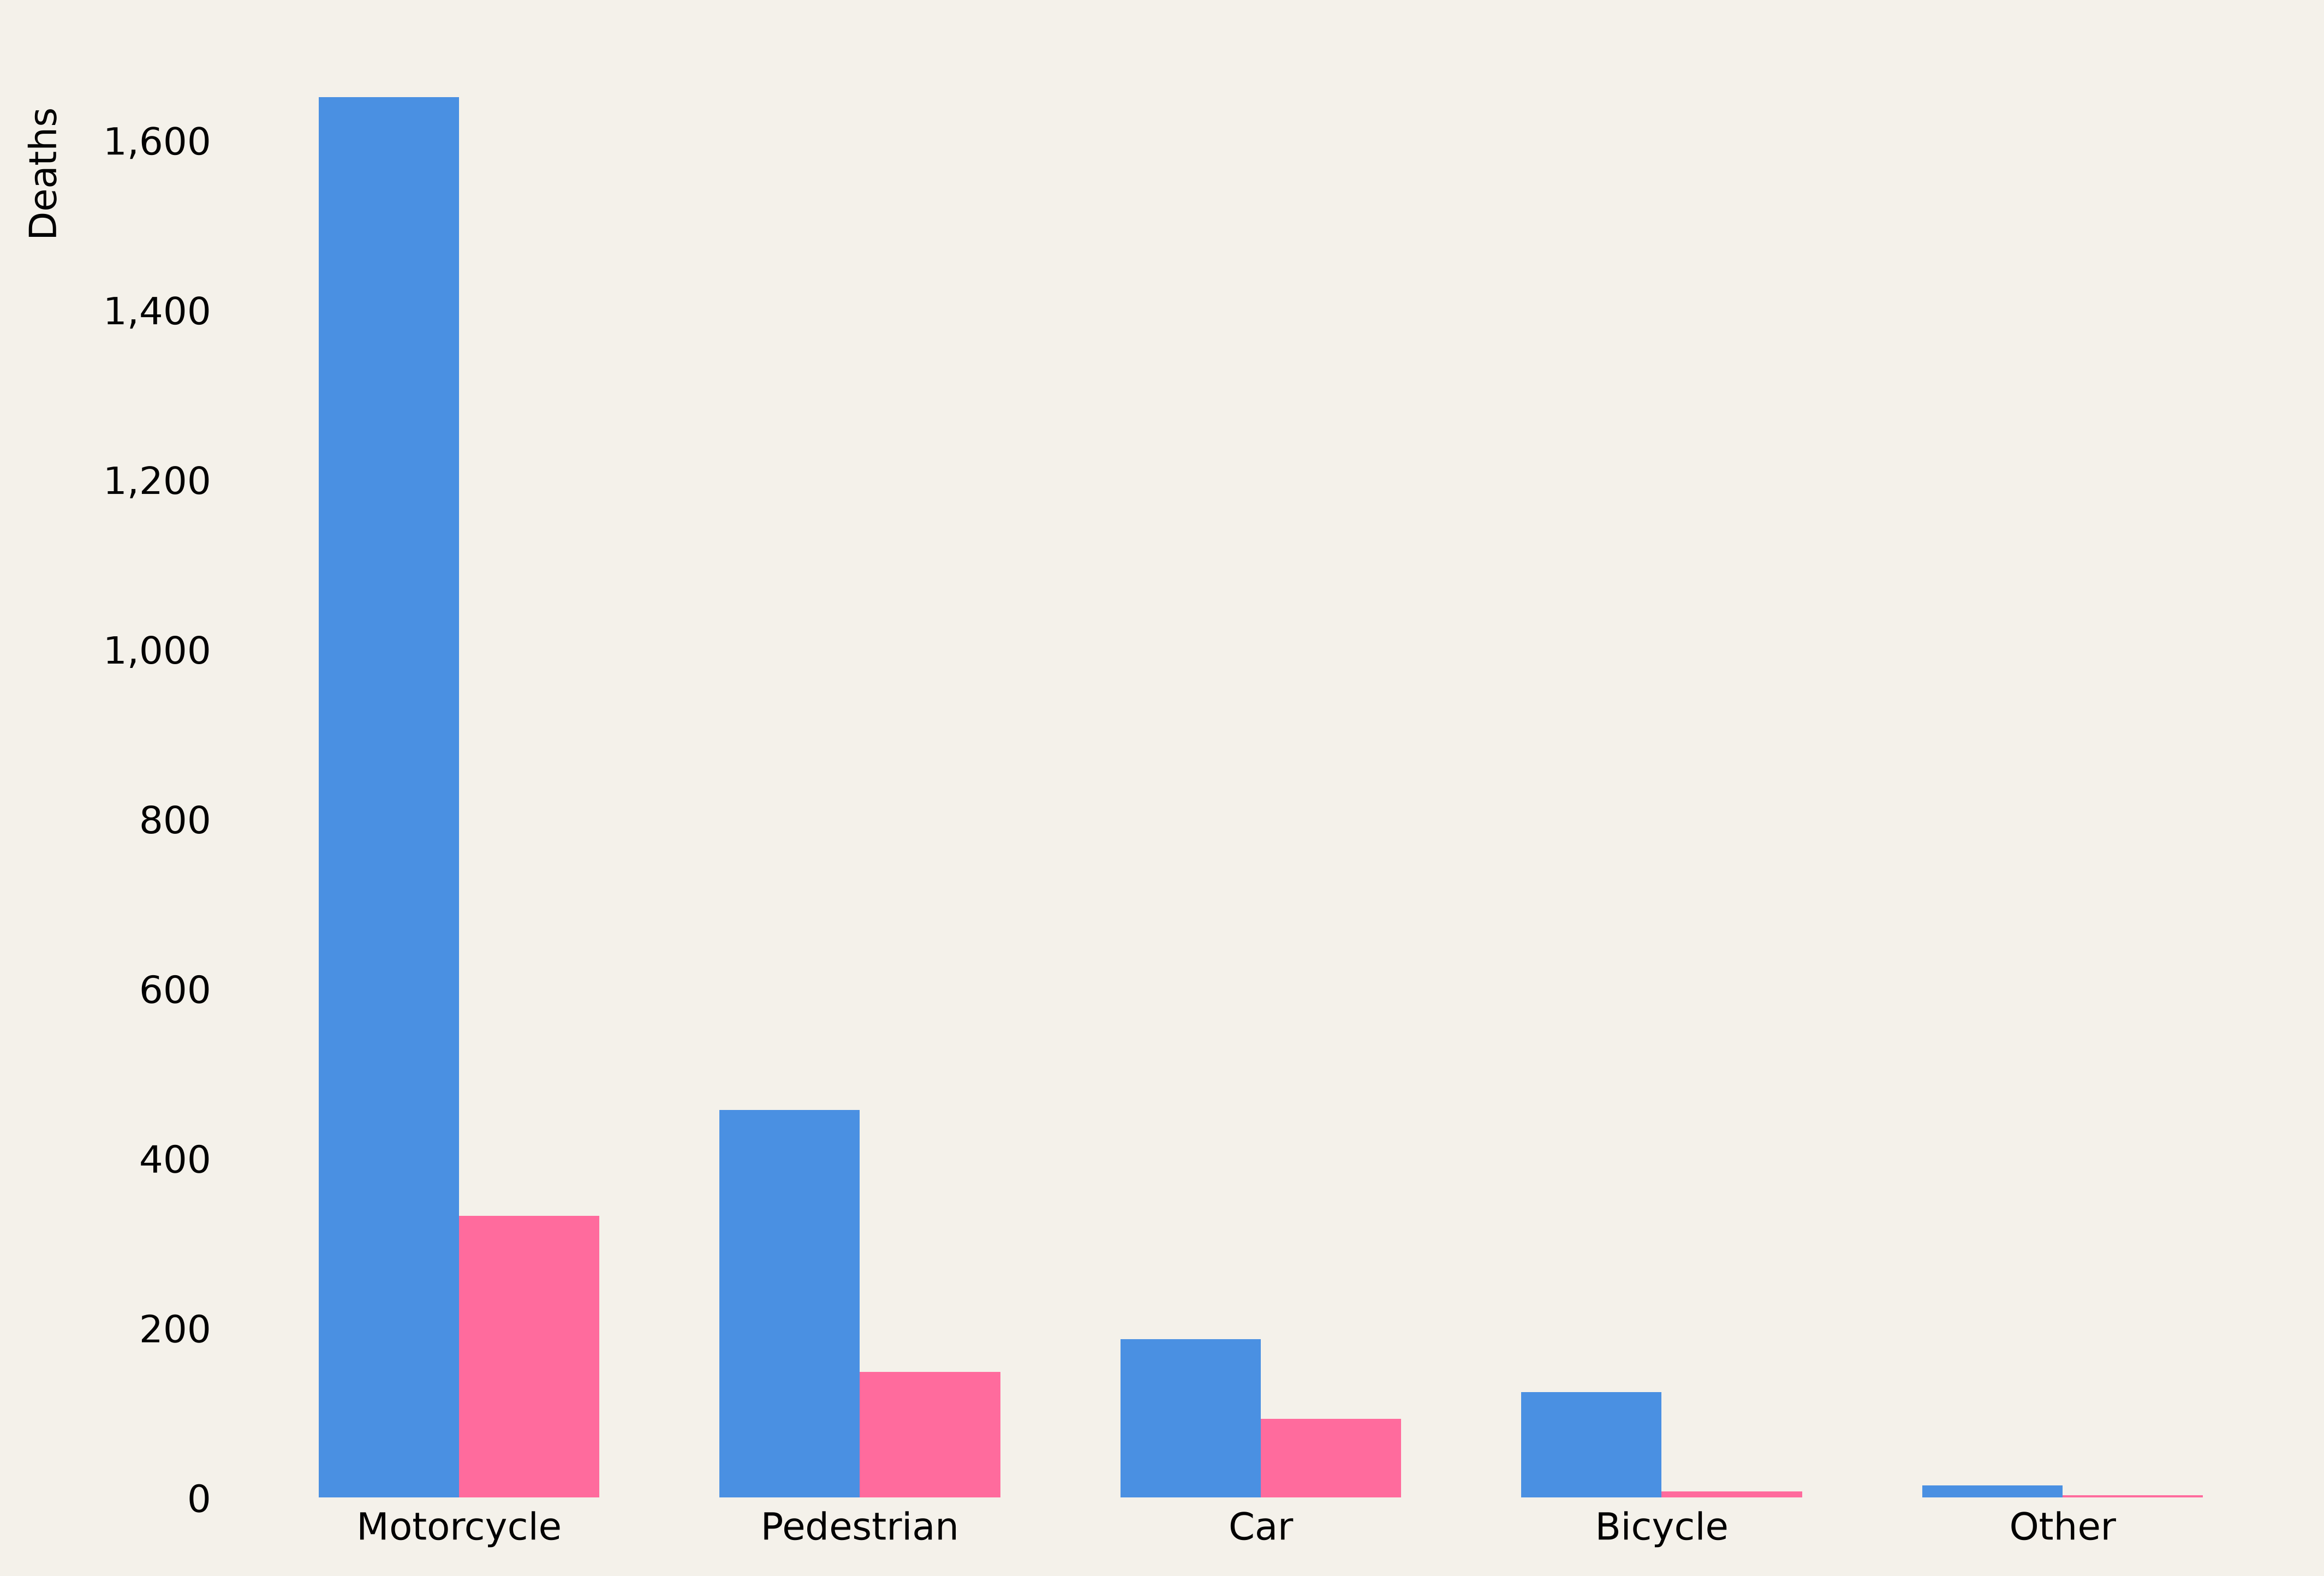

In [27]:
fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

width = 0.35
x = range(len(role_gender))

plt.bar([i - width / 2 for i in x], role_gender["HOMBRE"], width=width, color=men_color)
plt.bar([i + width / 2 for i in x], role_gender["MUJER"], width=width, color=women_color)

plt.xticks(ticks=x, labels=role_gender.index)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Deaths", labelpad=10, fontsize=10, y=0.9)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.show()

## Extra information

In [26]:
hipotesis_en = {
    "EXCESO DE VELOCIDAD": "Speeding",
    "DESOBEDECER SEÑALES DE TRÁNSITO": "Disobeying traffic signals",
    "EMBRIAGUEZ (ALCOHÓLICA Y NO ALCOHÓLICA)": "Drunk / drugged driving",
    "MALAS CONDICIONES DE LA VÍA": "Poor road conditions",
    "CRUZAR SIN OBSERVAR": "Crossing without looking",
    "NO MANTENER DISTANCIA DE SEGURIDAD": "Not keeping safe distance",
}

top_hipotesis = (
    df[df["Hipotesis"] != "SIN INFORMACIÓN"]
    .groupby("Hipotesis")
    .size()
    .reset_index(name="Deaths")
    .nlargest(columns="Deaths", n=6)
    .assign(Hipotesis=lambda d: d["Hipotesis"].map(hipotesis_en))
    .rename(columns={"Hipotesis": "Cause"})
)